In [3]:
import os
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch.utils.data import Dataset
from sklearn.metrics import classification_report, confusion_matrix
from transformers import RobertaTokenizer, RobertaForSequenceClassification, Trainer, TrainingArguments
from src.utils import load_config
from src.data_loader import FakeNewsDataset

D:\Skills\Python\Resume Projects\Fake_News_Detection\spacy_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


INFO:src.utils:Configuration file successfully loaded from: ..\configs\roberta_config.yaml


Targeting active hardware accelerator device: CUDA
Loading tokenizer and trained sequence classification weights...


INFO:httpx:HTTP Request: HEAD https://huggingface.co/roberta-base/resolve/main/tokenizer_config.json "HTTP/1.1 200 OK"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/roberta-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/FacebookAI/roberta-base/tree/main/additional_chat_templates?recursive=false&expand=false "HTTP/1.1 404 Not Found"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/roberta-base/tree/main?recursive=true&expand=false "HTTP/1.1 307 Temporary Redirect"
INFO:httpx:HTTP Request: GET https://huggingface.co/api/models/FacebookAI/roberta-base/tree/main?recursive=true&expand=false "HTTP/1.1 200 OK"
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 12143.74it/s]


Loading blind test data slice from: ../data/processed/processed_test_df.csv
Executing final forward propagation test matrix run...



==================== FINAL ROBERTA SYSTEM BLIND TEST REPORT ====================
              precision    recall  f1-score   support

        Fake     0.9993    0.9986    0.9989      4215
        Real     0.9988    0.9994    0.9991      5193

    accuracy                         0.9990      9408
   macro avg     0.9991    0.9990    0.9990      9408
weighted avg     0.9990    0.9990    0.9990      9408



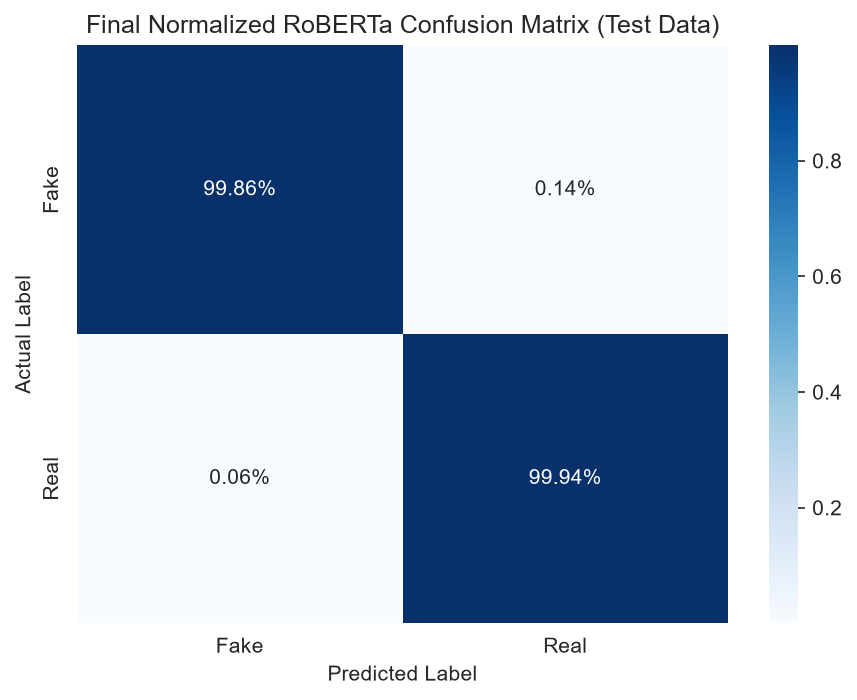

In [4]:
if __name__ == "__main__":
    config = load_config(config_path=os.path.join("..", "configs", "roberta_config.yaml"))
    model_dir = "../artifacts/roberta_model/checkpoint-8232"

    if not os.path.exists(model_dir):
        raise FileNotFoundError(f"Trained weights not found at {model_dir}. Please unzip your drive export here.")

    # Hardware Allocation Fallback Configuration
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Targeting active hardware accelerator device: {str(device).upper()}")

    print("Loading tokenizer and trained sequence classification weights...")
    tokenizer = RobertaTokenizer.from_pretrained('roberta-base')
    model = RobertaForSequenceClassification.from_pretrained(model_dir)
    # model.to(device)
    # model.eval()

    # Ingest the completely untouched test CSV
    test_path = '../data/processed/processed_test_df.csv'
    print(f"Loading blind test data slice from: {test_path}")
    test_df = pd.read_csv(test_path).dropna(subset=['text']).reset_index(drop=True)

    # Pack into PyTorch format
    test_dataset = FakeNewsDataset(
        texts=test_df['text'].tolist(),
        labels=test_df['label'].tolist(),
        tokenizer=tokenizer,
        max_len=config['model']['max_length']
    )

    # 4. Initialize evaluation configurations safely for local CPU fallback
    training_args = TrainingArguments(
        output_dir="artifacts/temp_eval",
        per_device_eval_batch_size=32,  # Batch size 32 is highly optimized for local memory extraction
        fp16=True
    )

    trainer = Trainer(model=model, args=training_args)

    # Run inference and extract probabilities
    print("Executing final forward propagation test matrix run...")
    predictions = trainer.predict(test_dataset)

    y_pred = np.argmax(predictions.predictions, axis=1)
    y_true = test_df['label'].values

    # ==================== METRICS OUTPUT REPORT ====================
    print("\n" + "="*20 + " FINAL ROBERTA SYSTEM BLIND TEST REPORT " + "="*20)
    print(classification_report(y_true, y_pred, target_names=['Fake', 'Real'], digits=4))

    # Calculate and render the Final Confusion Matrix
    cm = confusion_matrix(y_true, y_pred)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

    plt.figure(figsize=(7, 5), dpi=150)
    sns.heatmap(cm_normalized, annot=True, fmt=".2%", cmap="Blues",
                xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.title('Final Normalized RoBERTa Confusion Matrix (Test Data)')
    plt.ylabel('Actual Label')
    plt.xlabel('Predicted Label')
    plt.show()

Overfitting: True (Confirmed by $\text{Validation Loss} \approx 2 \times \text{Training Loss}$).Classification State: Highly discriminative but poorly calibrated (extreme, binary prediction confidence).